![ATARRI logos](img/logos.png)

# 4.1 Visualising dust models with plotting libraries

#### Objective 

The objective of this notebook is to provide plotting techniques with Python libraries to visualise MONARCH forecasts.

## Introduction

Having learned reviewed our model data structure and basic data operations, we will now visualise our MONARCH dust forecasts into maps. This will help us understand the spatial distributions and variations of our data, and is especially helpful when looking at our dust event.

For this we will look at two examples: one with dust AOD, and one with dust concentration.

To achieve these visualisations, we will need the `matplotlib` and `cartopy` libraries.

In [1]:
import os
from pathlib import Path
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm

In [2]:
from IPython.utils.io import capture_output
with capture_output():
    %run ../functions/functions1.ipynb

## Example 1: Viewing dust optical depth

For the following example, we will start by opening a dust optical depth dataset from the SDS-WAS multi-model ensemble.

In [3]:
root_dir = Path('/shared/data/exp_to_interp/sdswas/regional/3hourly')

In [4]:
od_path = os.path.join(root_dir, "od550_dust/od550_dust_2025030500.nc")
ds_sdswas = xr.open_dataset(od_path)

In [5]:
ds_sdswas

<xarray.Dataset> Size: 2MB
Dimensions:     (time: 25, latitude: 130, longitude: 184)
Coordinates:
  * time        (time) datetime64[ns] 200B 2025-03-05 ... 2025-03-08
  * latitude    (latitude) float32 520B 0.25 0.75 1.25 ... 63.75 64.25 64.75
  * longitude   (longitude) float32 736B -26.75 -26.25 -25.75 ... 64.25 64.75
Data variables:
    OD550_DUST  (time, latitude, longitude) float32 2MB ...
Attributes:
    history:  Thu Mar  6 01:14:25 2025: ncap2 -O -v -s where(OD550_DUST < 0) ...
    NCO:      netCDF Operators version 4.8.1 (Homepage = http://nco.sf.net, C...

Next, we will specifically select our `od550_dust` variable. In order to correctly plot this later on, we must also select a timestep that we wish to visualise.

In [6]:
ds_dod = ds_sdswas["OD550_DUST"]
ds_dod = ds_dod.isel(time=0)
ds_dod

<xarray.DataArray 'OD550_DUST' (latitude: 130, longitude: 184)> Size: 96kB
[23920 values with dtype=float32]
Coordinates:
  * latitude   (latitude) float32 520B 0.25 0.75 1.25 1.75 ... 63.75 64.25 64.75
  * longitude  (longitude) float32 736B -26.75 -26.25 -25.75 ... 64.25 64.75
    time       datetime64[ns] 8B 2025-03-05
Attributes:
    description:  Dust AOD at 550 nm
    units:        unitless

To reduce cluttering in our plotting lines, we will store `lat`, `lon` and `time` into variables. For `time`, we will extract the value so it is readable later on.

In [7]:
lat_dod = ds_dod["latitude"]
lon_dod = ds_dod["longitude"]
time_dod = ds_dod["time"].values
time_dod

np.datetime64('2025-03-05T00:00:00.000000000')

In [9]:
lon_dod

<xarray.DataArray 'longitude' (longitude: 184)> Size: 736B
array([-26.75, -26.25, -25.75, -25.25, -24.75, -24.25, -23.75, -23.25, -22.75,
       -22.25, -21.75, -21.25, -20.75, -20.25, -19.75, -19.25, -18.75, -18.25,
       -17.75, -17.25, -16.75, -16.25, -15.75, -15.25, -14.75, -14.25, -13.75,
       -13.25, -12.75, -12.25, -11.75, -11.25, -10.75, -10.25,  -9.75,  -9.25,
        -8.75,  -8.25,  -7.75,  -7.25,  -6.75,  -6.25,  -5.75,  -5.25,  -4.75,
        -4.25,  -3.75,  -3.25,  -2.75,  -2.25,  -1.75,  -1.25,  -0.75,  -0.25,
         0.25,   0.75,   1.25,   1.75,   2.25,   2.75,   3.25,   3.75,   4.25,
         4.75,   5.25,   5.75,   6.25,   6.75,   7.25,   7.75,   8.25,   8.75,
         9.25,   9.75,  10.25,  10.75,  11.25,  11.75,  12.25,  12.75,  13.25,
        13.75,  14.25,  14.75,  15.25,  15.75,  16.25,  16.75,  17.25,  17.75,
        18.25,  18.75,  19.25,  19.75,  20.25,  20.75,  21.25,  21.75,  22.25,
        22.75,  23.25,  23.75,  24.25,  24.75,  25.25,  25.75,  26.25,  26.75,
        27.25,  27.75,  28.25,  28.75,  29.25,  29.75,  30.25,  30.75,  31.25,
        31.75,  32.25,  32.75,  33.25,  33.75,  34.25,  34.75,  35.25,  35.75,
        36.25,  36.75,  37.25,  37.75,  38.25,  38.75,  39.25,  39.75,  40.25,
        40.75,  41.25,  41.75,  42.25,  42.75,  43.25,  43.75,  44.25,  44.75,
        45.25,  45.75,  46.25,  46.75,  47.25,  47.75,  48.25,  48.75,  49.25,
        49.75,  50.25,  50.75,  51.25,  51.75,  52.25,  52.75,  53.25,  53.75,
        54.25,  54.75,  55.25,  55.75,  56.25,  56.75,  57.25,  57.75,  58.25,
        58.75,  59.25,  59.75,  60.25,  60.75,  61.25,  61.75,  62.25,  62.75,
        63.25,  63.75,  64.25,  64.75], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 736B -26.75 -26.25 -25.75 ... 64.25 64.75
    time       datetime64[ns] 8B 2025-03-05
Attributes:
    standard_name:  longitude
    long_name:      longitude
    units:          degrees_east
    axis:           X

We will now create our plot with the following `pcolormesh` inputs:

- `lon_dod`: longitude coordinates.
- `lat_dod`: latitude coordinates.
- `ds_dod`: data variable, which must be a 2D array that matches the spatial grid of our selected lat/lon.
- `transform=ccrs.PlateCarree()`: projection keyword to specify how our input coordinates should be interpreted.
- `cmap`: specifies the colormap for our plot (optional).
- `norm`: applies normalisation to our data variable values (i.e. groups our values into ranges for the display) (optional).

For this last input, we will create a list with the normalisation ranges we want to add to our dust AOD. These can be personalised according to your interest, but in our case we will use two helper functions to align our plots with the BDRC visualisation tools.

To produce our colormap, we will use the `get_cmap_bdrc()` function. This will return the same colour scheme from the BDRC maps, and we will call it to return the `cmap` object. Next, to group our values into the same ranges as BDRC, we will use the `get_normalised_bdrc()` function. This requires two inputs: the type of dust variable and the BDRC cmap object. 

In [11]:
cmap_bdrc = get_cmap_bdrc()
norm_dod = get_normalised_bdrc("od550_dust", cmap_bdrc)

Finally, we use `matplotlib` to plot AOD at a specific timestep, using longitude and latitude as inputs. We will also add a dynamic title by incorporating our time value. By adding `cartopy`, we can add more detail to our map, such as setting coastlines and country borders.

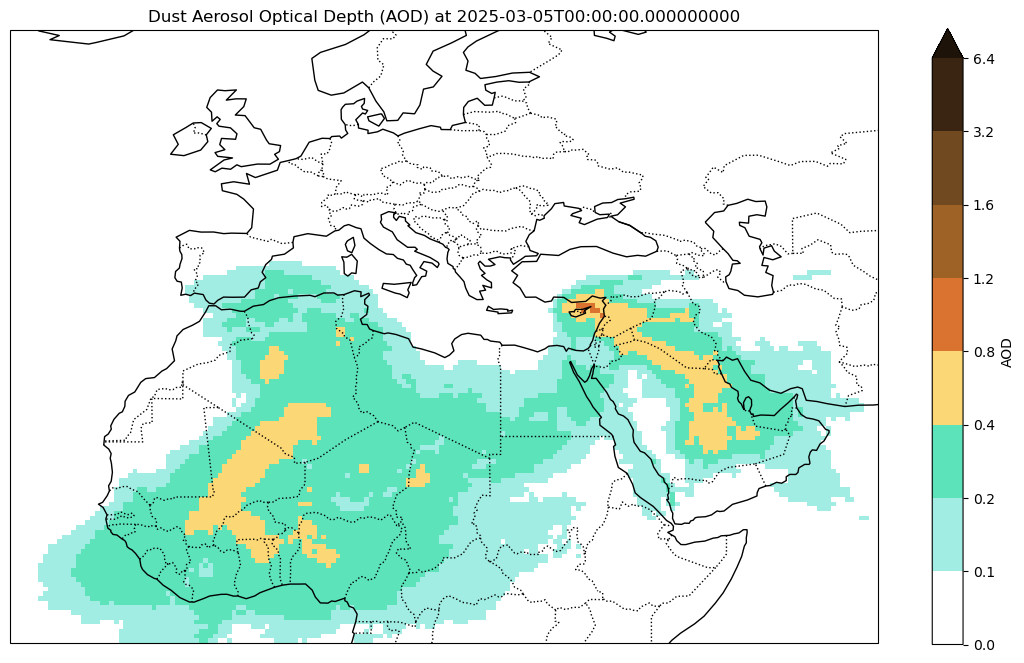

In [14]:
# Create the plot
fig, ax = plt.subplots(figsize=(14, 8), subplot_kw={"projection": ccrs.PlateCarree()})

# Plot the data
p = ax.pcolormesh(lon_dod, # add your DOD lon
                  lat_dod, # add your DOD lat
                  ds_dod, # add your DOD dataset
                  transform=ccrs.PlateCarree(),
                  cmap=cmap_bdrc,
                  norm=norm_dod
                 )

# Add features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.set_title(f"Dust Aerosol Optical Depth (AOD) at {time_dod}")

# Add colorbar
cbar = plt.colorbar(p, ax=ax, orientation="vertical", label="AOD")

# Show the plot
plt.show()

## Example 2: Viewing dust concentration

We will now do the same for dust concentration. Let us first load the dataset:

In [27]:
ds_monarch = xr.open_dataset('/shared/data/exp_to_interp/monarch/regional/3hourly/original_files/2025030512_3H_SDSWAS_NMMB-BSC-v2_OPER.nc')
ds_monarch

<xarray.Dataset> Size: 3GB
Dimensions:       (time: 29, lat: 825, lon: 1650, lev: 14)
Coordinates:
  * time          (time) datetime64[ns] 232B 2025-03-05T12:00:00 ... 2025-03-09
  * lat           (lat) float64 7kB -10.95 -10.85 -10.75 ... 71.25 71.35 71.45
  * lon           (lon) float64 13kB -62.95 -62.85 -62.75 ... 101.8 101.9 102.0
  * lev           (lev) float64 112B 0.0 250.0 500.0 ... 8e+03 1e+04 1.2e+04
Data variables:
    dust_ext_sfc  (time, lat, lon) float32 158MB ...
    dust_load     (time, lat, lon) float32 158MB ...
    dust_depd     (time, lat, lon) float32 158MB ...
    dust_depw     (time, lat, lon) float32 158MB ...
    od550_dust    (time, lat, lon) float32 158MB ...
    sconc_dust    (time, lev, lat, lon) float32 2GB ...
Attributes:
    Domain:                     Regional
    Conventions:                CF-1.7
    comment:                    Generated on cirrus
    history_of_appended_files:  Wed Mar  5 18:04:20 2025: Appended file od550...
    NCO:                        netCDF Operators version 4.8.1 (Homepage = ht...
    history:                    Thu Mar  6 11:32:01 2025: ncap2 -O -v -s wher...

In [29]:
ds_monarch.lev

<xarray.DataArray 'lev' (lev: 14)> Size: 112B
array([    0.,   250.,   500.,   750.,  1000.,  1500.,  2000.,  3000.,  4000.,
        5000.,  6000.,  8000., 10000., 12000.])
Coordinates:
  * lev      (lev) float64 112B 0.0 250.0 500.0 750.0 ... 8e+03 1e+04 1.2e+04

In the case of `sconc_dust`, we will chunk the dataset across `time` and `lev`, as we will be subsetting them. We will also subset our data for `time=4` and `lev=4`, which puts our time at `2025-03-06 00:00:00` and `1000.0`m altitude.

In [25]:
ds_monarch = ds_monarch.chunk({"time": 1, "lev": 1}) # chunking to lazy load datasets
ds_sconc = ds_monarch["sconc_dust"] # select dust variable
ds_sconc = ds_sconc.isel(time=4, lev=2) * 2 # subset time and vertical level
ds_sconc = ds_sconc.compute()

In [26]:
ds_sconc

<xarray.DataArray 'sconc_dust' (lat: 825, lon: 1650)> Size: 5MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(825, 1650), dtype=float32)
Coordinates:
  * lat      (lat) float64 7kB -10.95 -10.85 -10.75 -10.65 ... 71.25 71.35 71.45
  * lon      (lon) float64 13kB -62.95 -62.85 -62.75 ... 101.8 101.9 102.0
    lev      float64 8B 500.0
    time     datetime64[ns] 8B 2025-03-06

To make our plot more readible, we will convert our units to µg/m3. Remember that this is strictly optional.

In [18]:
ds_sconc = ds_sconc * 1e9 # optional conversion to µg/m3

We then repeat the same steps as before, storing our `lat`, `lon`, `time` and `lev` in variables for easier readibility later on.

In [19]:
lat_sconc = ds_sconc.lat
lon_sconc = ds_sconc.lon
time_sconc = ds_sconc.time.values
lev_sconc = ds_sconc.lev.values

In [21]:
time_sconc

np.datetime64('2025-03-06T00:00:00.000000000')

Finally, we will plot dust concentration with our needed inputs with the same structure as dust AOD, but we will create a new `norm` object specifically for concentration.

In [23]:
cmap_bdrc = get_cmap_bdrc()
norm_sconc = get_normalised_bdrc("sconc_dust", cmap_bdrc)

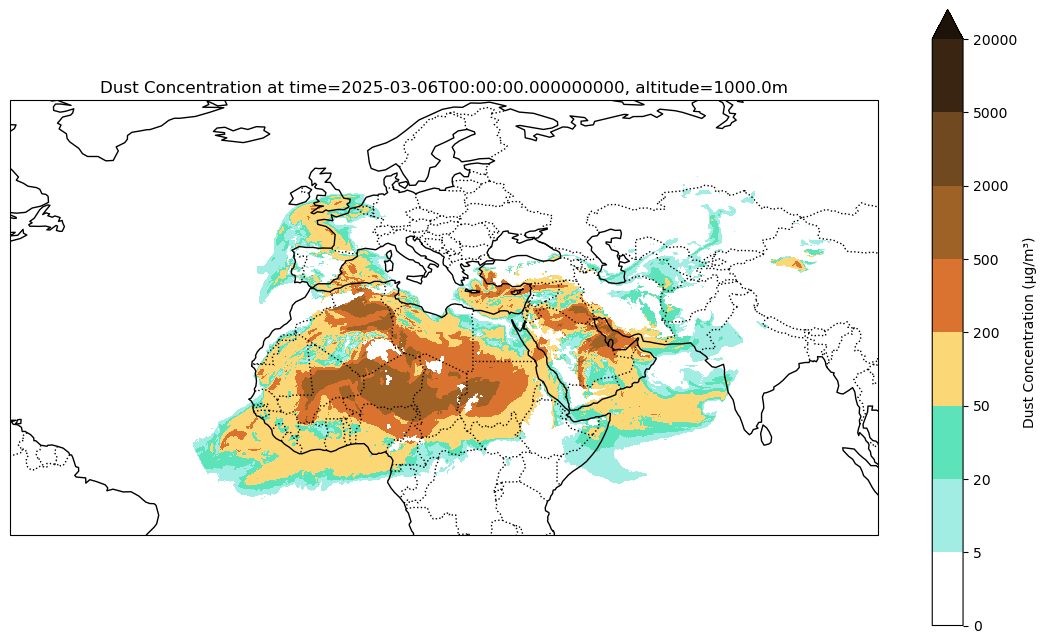

In [24]:
# Create the plot
fig, ax = plt.subplots(figsize=(14, 8), subplot_kw={"projection": ccrs.PlateCarree()})

# Plot the data
p = ax.pcolormesh(lon_sconc, # add your sconc lon
                  lat_sconc, # add your sconc lat
                  ds_sconc, # add your sconc ds
                  transform=ccrs.PlateCarree(),
                  cmap=cmap_bdrc,
                  norm=norm_sconc 
                 )

# Add features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.set_title(f"Dust Concentration at time={time_sconc}, altitude={lev_sconc}m")  # Dynamic title

# Add colorbar
cbar = plt.colorbar(p, ax=ax, orientation="vertical", label="Dust Concentration (µg/m³)")

# Show the plot
plt.show()

## References and further reading

- Xarray chunking [documentation](https://docs.xarray.dev/en/stable/generated/xarray.DataArray.chunk.html)
- Matplotlib [general documentation](https://matplotlib.org/stable/users/explain/quick_start.html)
- Matplotlib `.pyplot.pcolormesh` [documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pcolormesh.html)
- Cartopy [general documentation](https://scitools.org.uk/cartopy/docs/latest/reference/generated/cartopy.crs.CRS.html)
- Path [documentation](https://docs.python.org/3/library/pathlib.html)
- `os` [documentation](https://docs.python.org/3/library/os.html)

<table style="width:100%;">
    <tr>
        <td></td>
        <td style="text-align: center;"><a href="VT2-2-combining_MONARCH_datasets.ipynb" style="font-size: 18px;">Next ➡</a></td>
    </tr
</table>